In [1]:
# ECO5012_analysis.ipynb
# 100471173
# May 2026

# these are the libraries i need to make this work
import pandas as pd
import numpy as np
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import plotly.express as px
from datetime import datetime

print('all libraries loaded!')

all libraries loaded!


In [2]:
# downloading UK GDP data from FRED
# setting the date range i want
start = datetime(2000, 1, 1)
end = datetime(2023, 12, 31)

# CLVMNACSCAB1GQUK is the FRED code for UK Real GDP
gdp_raw = web.DataReader('CLVMNACSCAB1GQUK', 'fred', start, end)

# renaming the column so its easier to read
gdp_raw.columns = ['GDP']

# working out the percentage change between each quarter
# this gives us the growth rate rather than the actual GDP level
gdp_growth = gdp_raw.pct_change() * 100

# removing the first row because it has nothing to compare to
gdp_growth = gdp_growth.dropna()

# renaming the column
gdp_growth.columns = ['GDP_Growth']

print('UK GDP data downloaded!')
gdp_growth.head()

UK GDP data downloaded!


,GDP_Growth
DATE,
2000-04-01,0.605956
2000-07-01,0.293415
2000-10-01,0.236188
2001-01-01,1.164969
2001-04-01,0.772287


In [3]:
# downloading UK business confidence data from FRED
# this is my sentiment proxy - it measures how confident businesses feel
# BSCICP02GBM460S is the FRED code for UK Business Confidence (OECD)
# above 0 = businesses feel good, below 0 = businesses feel worried

sentiment_raw = web.DataReader('BSCICP02GBM460S', 'fred', start, end)

# renaming the column
sentiment_raw.columns = ['Sentiment']

print('UK Business Confidence data downloaded!')
sentiment_raw.head()

UK Business Confidence data downloaded!


,Sentiment
DATE,
2000-01-01,-2.744717
2000-02-01,-5.151341
2000-03-01,-6.168237
2000-04-01,-10.974792
2000-05-01,-9.815079


In [4]:
# the sentiment data is monthly but GDP is quarterly
# so i need to convert it by averaging the 3 months in each quarter
sentiment_quarterly = sentiment_raw.resample('QS').mean()

# joining the two datasets together on matching dates
df = pd.merge(gdp_growth, sentiment_quarterly,left_index=True,right_index=True,how='inner')

# removing any missing data
df = df.dropna()

# saving the final dataset as a csv file
df.to_csv('uk_gdp_sentiment_data.csv')

print(f'dataset ready! number of quarters: {len(df)}')
df.head()

dataset ready! number of quarters: 82


,GDP_Growth,Sentiment
DATE,,
2000-04-01,0.605956,-11.229882
2000-07-01,0.293415,-9.091710
2000-10-01,0.236188,-3.764048
2001-01-01,1.164969,-8.909757
2001-04-01,0.772287,-14.225821


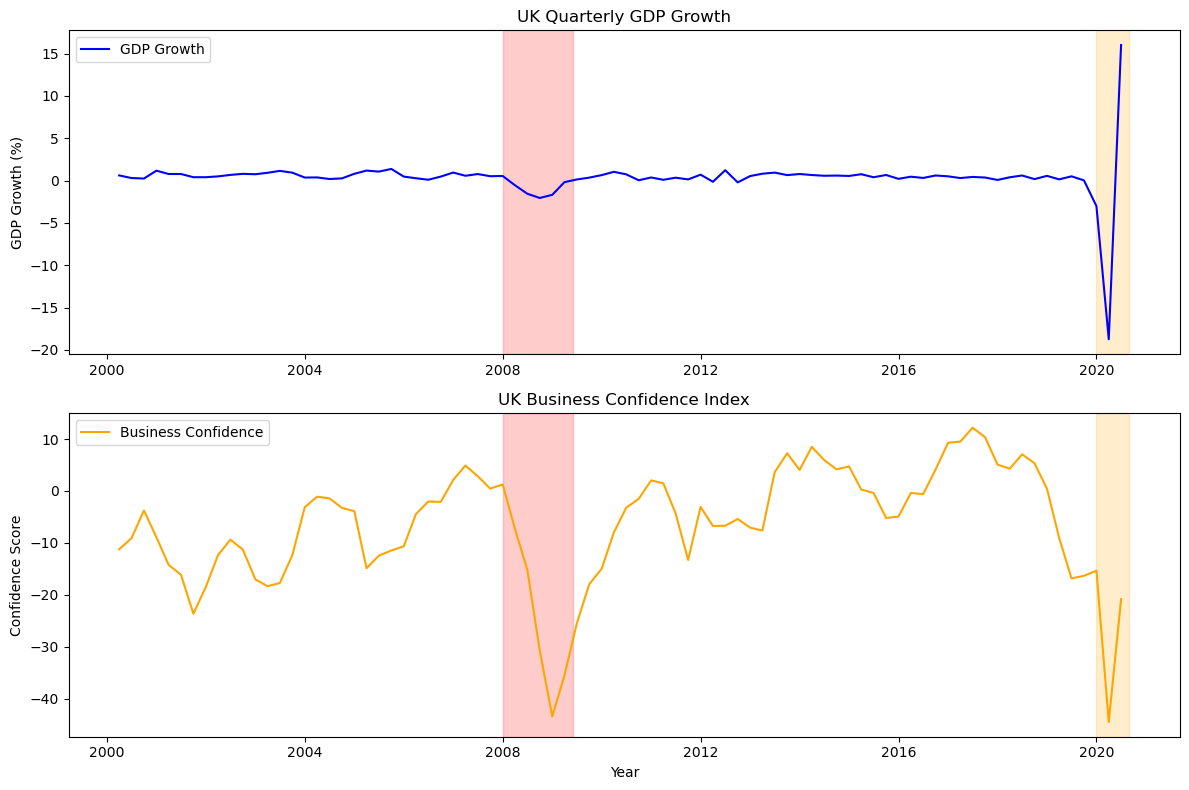

In [5]:
# making time series plots of both variables
# shading the crisis periods so they stand out

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# top plot - GDP growth
ax1.plot(df.index, df['GDP_Growth'], color='blue', label='GDP Growth')
ax1.set_title('UK Quarterly GDP Growth')
ax1.set_ylabel('GDP Growth (%)')
ax1.legend()
ax1.axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2009-06-01'), color='red', alpha=0.2, label='2008 Crisis')
ax1.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2020-09-01'), color='orange', alpha=0.2, label='COVID-19')

# bottom plot - business confidence
ax2.plot(df.index, df['Sentiment'], color='orange', label='Business Confidence')
ax2.set_title('UK Business Confidence Index')
ax2.set_ylabel('Confidence Score')
ax2.set_xlabel('Year')
ax2.legend()
ax2.axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2009-06-01'), color='red', alpha=0.2)
ax2.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2020-09-01'), color='orange', alpha=0.2)

plt.tight_layout()
plt.savefig('timeseries_plot.png')
plt.show()

overall correlation: 0.266
crisis period correlation: 0.498
normal period correlation: 0.085


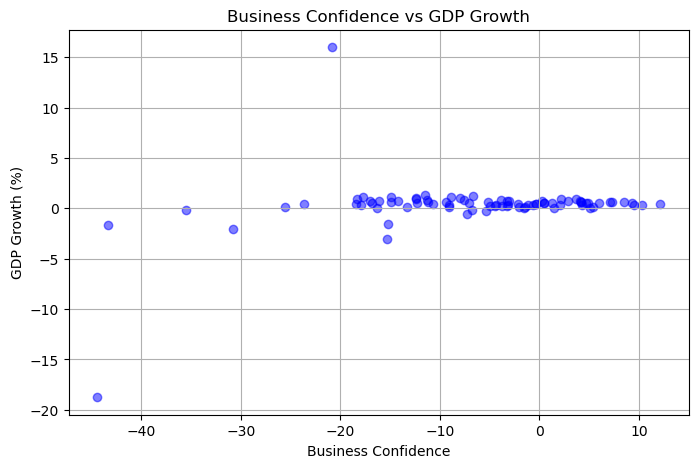

In [6]:
# calculating the correlation between GDP and business confidence
overall_corr = df['GDP_Growth'].corr(df['Sentiment'])
print(f'overall correlation: {overall_corr:.3f}')

# checking if correlation is stronger during crisis periods
crisis = df['2008':'2009']
normal = df['2010':'2019']

print(f'crisis period correlation: {crisis["GDP_Growth"].corr(crisis["Sentiment"]):.3f}')
print(f'normal period correlation: {normal["GDP_Growth"].corr(normal["Sentiment"]):.3f}')

# scatter plot to show the relationship visually
plt.figure(figsize=(8, 5))
plt.scatter(df['Sentiment'], df['GDP_Growth'], color='blue', alpha=0.5)
plt.xlabel('Business Confidence')
plt.ylabel('GDP Growth (%)')
plt.title('Business Confidence vs GDP Growth')
plt.grid(True)
plt.savefig('correlation_plot.png')
plt.show()

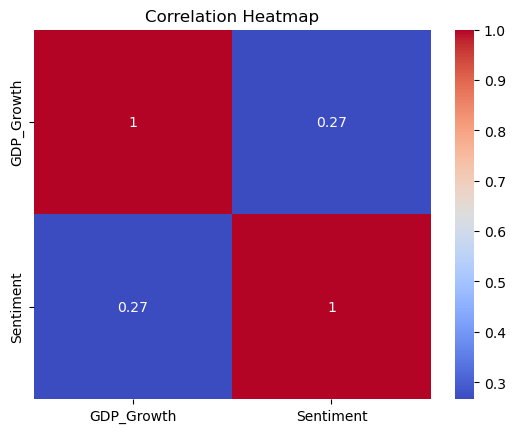

In [7]:
# making a heatmap to show the correlation visually
# seaborn makes this really easy

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('heatmap.png')
plt.show()

In [8]:
# generating synthetic data as required by step 2.2
# using numpy to create 100 fake quarters of data

# setting a seed so i get the same results every time
np.random.seed(42)

# creating 100 fake sentiment values
# mean of -5 and std of 10 matches my real data roughly
synthetic_sentiment = np.random.normal(-5, 10, 100)

# creating fake GDP using my regression equation
# GDP = 0.77 + 0.1088 x sentiment + random error
synthetic_gdp = 0.77 + 0.1088 * synthetic_sentiment + np.random.normal(0, 1, 100)

# putting it into a dataframe
synthetic_df = pd.DataFrame({'Sentiment': synthetic_sentiment, 'GDP_Growth': synthetic_gdp})

print('synthetic data created!')
synthetic_df.head()

synthetic data created!


,Sentiment,GDP_Growth
0,-0.032858,-0.648946
1,-6.382643,-0.345077
2,1.476885,0.587971
3,10.230299,1.080779
4,-7.341534,-0.190045


In [9]:
# setting up and running the regression model
# the equation from the brief is:
# GDP_Growth = b0 + b1*GDP_Lagged + bS*Sentiment + error

# creating a lagged GDP variable (last quarters GDP growth)
df['GDP_Lagged'] = df['GDP_Growth'].shift(1)

# removing the first row which has no lagged value
df = df.dropna()

# setting up the predictors - lagged GDP and sentiment
X = df[['GDP_Lagged', 'Sentiment']]

# adding a constant for the intercept
X = sm.add_constant(X)

# y is what i am trying to predict
Y = df['GDP_Growth']

# running the regression
model = sm.OLS(Y, X)
results = model.fit()

# printing the results
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             GDP_Growth   R-squared:                       0.358
Model:                            OLS   Adj. R-squared:                  0.341
Method:                 Least Squares   F-statistic:                     21.74
Date:                Mon, 18 May 2026   Prob (F-statistic):           3.14e-08
Time:                        17:51:25   Log-Likelihood:                -181.10
No. Observations:                  81   AIC:                             368.2
Df Residuals:                      78   BIC:                             375.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1476      0.303      3.784      0.0

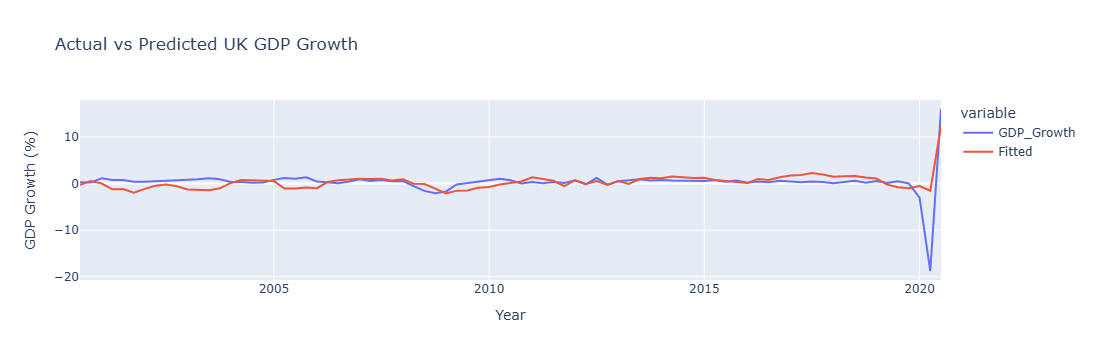

In [10]:
# creating the replication plot using plotly
# this compares actual GDP growth with what my model predicted

# getting the fitted values from the regression
df['Fitted'] = results.fittedvalues

# creating an interactive line chart
fig = px.line(df, y=['GDP_Growth', 'Fitted'], title='Actual vs Predicted UK GDP Growth', labels={'value': 'GDP Growth (%)', 'DATE': 'Year'})

fig.show()